<a href="https://colab.research.google.com/github/JTHOMP801/Plant-Identification/blob/main/PlantDiseaseIdentification_JoeThompson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resnet50 EfficientNetB0 mobilnetv2/v3 maybe make one?

In [47]:
!pip install keras matplotlib numpy


In [48]:
!pip uninstall -y jax jaxlib

In [49]:
import tensorflow as tf
from tensorflow import keras

import os
from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import (EfficientNetV2B0, ResNet50, MobileNetV2)
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

In [50]:
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [51]:
base_path = '/content/drive/MyDrive/MLPLANT4_split_aug_cropped224'

In [52]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 4

backbones = {
    "EfficientNetV2B0": {
        "constructor": EfficientNetV2B0,
        "preprocess": effnet_preprocess,
        "input_size": (224, 224),
    },
    "ResNet50": {
        "constructor": ResNet50,
        "preprocess": resnet_preprocess,
        "input_size": (224, 224),
    },
    "MobileNetV2": {
        "constructor": MobileNetV2,
        "preprocess": mobilenet_preprocess,
        "input_size": (224, 224),
    },
}

Randomize Images

In [53]:
def get_generator(model_name):
    if model_name not in backbones:#if model name isnt in backbones
        raise ValueError(
            f"Unknown model_name '{model_name}'. "
            f"Expected one of: {list(backbones.keys())}"
        )

    backbone_cfg = backbones[model_name]
    preprocess = backbone_cfg["preprocess"]
    IMG_SIZE = backbone_cfg["input_size"]   # (224, 224)
    BATCH_SIZE = 32  # or use a global if you already defined one

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess,
        rotation_range=15,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess
    )

    # Load the images from folders
    train_generator = train_datagen.flow_from_directory(
        directory=os.path.join(base_path, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical"
    )

    val_generator = val_test_datagen.flow_from_directory(
        directory=os.path.join(base_path, "val"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical"
    )

    test_generator = val_test_datagen.flow_from_directory(
        directory=os.path.join(base_path, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False  # important for evaluation later
    )

    return train_generator, val_generator, test_generator


In [54]:
train_gen, val_gen, test_gen = get_generator("ResNet50")

Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.


dont use this one

In [55]:
"""
preprocess = model
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
#Randommize training images
# Training data generator
train_datagen = ImageDataGenerator(
    #rescale=1./255,  # normalize pixel values to [0,1]
    rotation_range=15,  # randomly rotate images
    zoom_range=0.1,     # random zoom
    width_shift_range=0.1,  # random horizontal shift
    height_shift_range=0.1, # random vertical shift
    horizontal_flip=True  # randomly flip images horizontally
)

#validation/test data generator
val_test_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
)
# Load the images from folders
train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(base_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(base_path, 'val'),
    target_size=IMG_SIZE, # resize images to 224x224
    batch_size=BATCH_SIZE, #32
    class_mode='categorical' #hot one encoded classes
)
test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(base_path, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # important for evaluation later
)
"""

"\npreprocess = model\nIMG_SIZE = (224, 224)\nBATCH_SIZE = 32\n#Randommize training images\n# Training data generator\ntrain_datagen = ImageDataGenerator(\n    #rescale=1./255,  # normalize pixel values to [0,1]\n    rotation_range=15,  # randomly rotate images\n    zoom_range=0.1,     # random zoom\n    width_shift_range=0.1,  # random horizontal shift\n    height_shift_range=0.1, # random vertical shift\n    horizontal_flip=True  # randomly flip images horizontally\n)\n\n#validation/test data generator\nval_test_datagen = ImageDataGenerator(\n    preprocessing_function=resnet_preprocess\n)\n# Load the images from folders\ntrain_generator = train_datagen.flow_from_directory(\n    directory=os.path.join(base_path, 'train'),\n    target_size=IMG_SIZE,\n    batch_size=BATCH_SIZE,\n    class_mode='categorical'\n)\n\nval_generator = val_test_datagen.flow_from_directory(\n    directory=os.path.join(base_path, 'val'),\n    target_size=IMG_SIZE, # resize images to 224x224\n    batch_size=BATC

In [56]:
# load resNet50 base no top
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# freeze
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)        # pool spatial features
x = Dense(256, activation='relu')(x)   # small dense layer
x = Dropout(0.5)(x)                    #dropout for regularization
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=outputs)

resnet_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [57]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
train_generator, val_generator, test_generator = get_generator("ResNet50")

Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.


In [59]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
classes = np.unique(labels)

weights = compute_class_weight( #pest and root condition classes smaller, weight all classes to help training
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weight = {i: w for i, w in enumerate(weights)} #assign weights
print("class_weight:", class_weight)

early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # stop if it doesn't improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,           # after 2 epochs with no improvement
    min_lr=1e-7
)

history_resnet = resnet_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

class_weight: {0: np.float64(0.7924731182795699), 1: np.float64(0.9448717948717948), 2: np.float64(1.28397212543554), 3: np.float64(1.1099397590361446)}
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 450s 9s/step - accuracy: 0.4342 - loss: 1.3997 - val_accuracy: 0.5574 - val_loss: 1.1219 - learning_rate: 1.0000e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 512ms/step - accuracy: 0.6187 - loss: 0.9543 - val_accuracy: 0.4918 - val_loss: 1.0479 - learning_rate: 1.0000e-04
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 509ms/step - accuracy: 0.6872 - loss: 0.7980 - val_accuracy: 0.5410 - val_loss: 1.0513 - learning_rate: 1.0000e-04
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 479ms/step - accuracy: 0.7395 - loss: 0.6891 - val_accuracy: 0.5574 - val_loss: 1.0923 - learning_rate: 1.0000e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 512ms/step - accuracy: 0.7659 - loss: 0.6317 - val_accuracy: 0.5246 - val_loss: 1.0584 - learning_rate: 5.0000e-05
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 490ms/step - accuracy:

In [60]:
test_loss, test_acc = resnet_model.evaluate(test_generator)
print(f"ResNet50 test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6567 - loss: 0.9036
ResNet50 test accuracy: 0.6567, test loss: 0.9036


Fine tune

In [61]:
resnet_base.trainable = True #unfreeze resnet base

set_trainable = False
for layer in resnet_base.layers: # only make the layers after conv4 block1 out trainable
    if layer.name == 'conv4_block1_out':
        set_trainable = True
    layer.trainable = set_trainable

for layer in resnet_base.layers: # set rest of them to untrainable
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for l in resnet_base.layers if l.trainable) # count number of traible and frozen layers
frozen_layers = sum(1 for l in resnet_base.layers if not l.trainable)
print('Trainable layers in resnet_base :' , trainable_layers)
print('Frozen layers in resnet_base    :' , frozen_layers)


resnet_model.compile(
    optimizer = Adam(learning_rate = 1e-5),
    loss= 'categorical_crossentropy',
    metrics = ['accuracy']
)

fine_tune_epochs = 10

history_resnet_finetune = resnet_model.fit(
    train_generator,
    epochs = fine_tune_epochs,
    validation_data= val_generator
)


Trainable layers in resnet_base : 58
Frozen layers in resnet_base    : 117
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 818ms/step - accuracy: 0.7117 - loss: 0.7133 - val_accuracy: 0.5738 - val_loss: 1.0673
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 484ms/step - accuracy: 0.8209 - loss: 0.4604 - val_accuracy: 0.6066 - val_loss: 1.0627
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 517ms/step - accuracy: 0.8935 - loss: 0.3052 - val_accuracy: 0.6230 - val_loss: 1.2526
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 518ms/step - accuracy: 0.9274 - loss: 0.2254 - val_accuracy: 0.6230 - val_loss: 1.1971
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 488ms/step - accuracy: 0.9322 - loss: 0.1832 - val_accuracy: 0.6721 - val_loss: 1.0617
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 519ms/step - accuracy: 0.9627 - loss: 0.1198 - val_accuracy: 0.6393 - val_loss: 1.5445
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 522ms/step - accuracy: 0.9634 - loss: 0.1100 - val_accuracy: 0.6721 - val_loss: 1.3349
Epoch 8/10
47/47 ━━━━━

In [62]:
test_loss, test_acc = resnet_model.evaluate(test_generator)
print(f"ResNet50 test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 983ms/step - accuracy: 0.7463 - loss: 1.1437
ResNet50 test accuracy: 0.7463, test loss: 1.1437


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Confusion matrix (raw counts):
[[20  0  0  1]
 [ 1 11  5  1]
 [ 0  2 10  1]
 [ 3  2  1  9]]


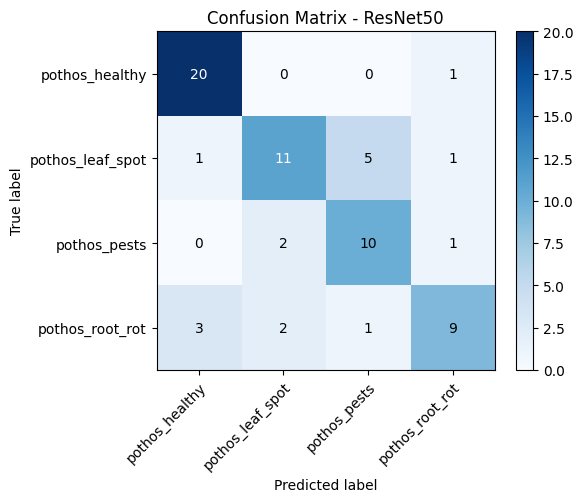


Classification report:
                  precision    recall  f1-score   support

  pothos_healthy       0.83      0.95      0.89        21
pothos_leaf_spot       0.73      0.61      0.67        18
    pothos_pests       0.62      0.77      0.69        13
 pothos_root_rot       0.75      0.60      0.67        15

        accuracy                           0.75        67
       macro avg       0.74      0.73      0.73        67
    weighted avg       0.75      0.75      0.74        67



In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()  # just in case
y_true = test_generator.classes                     # integer labels
class_labels = list(test_generator.class_indices.keys())

y_prob = resnet_model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (raw counts):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(class_labels)),
    yticks=np.arange(len(class_labels)),
    xticklabels=class_labels,
    yticklabels=class_labels,
    ylabel='True label',
    xlabel='Predicted label',
    title='Confusion Matrix - ResNet50'
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


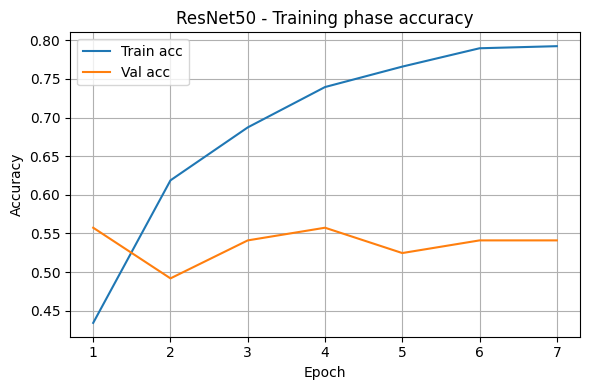

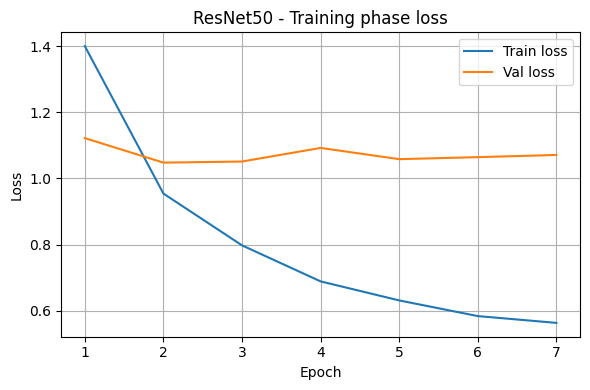

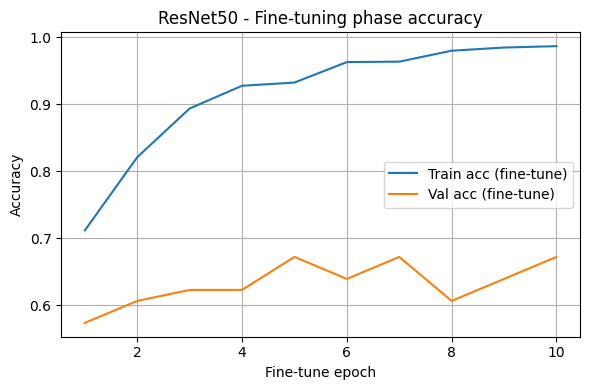

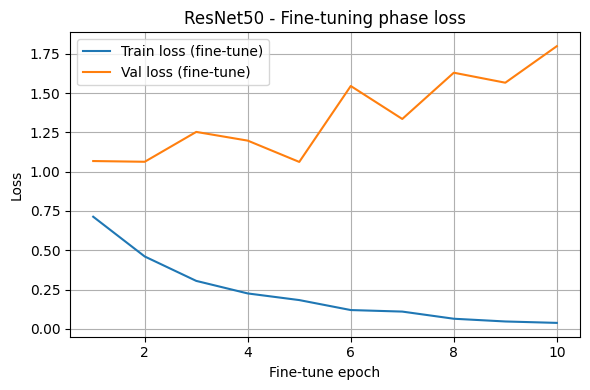

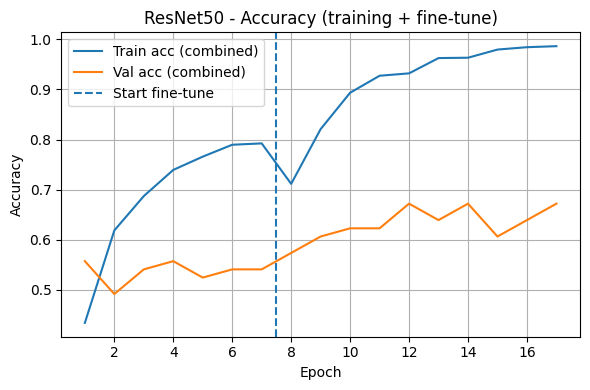

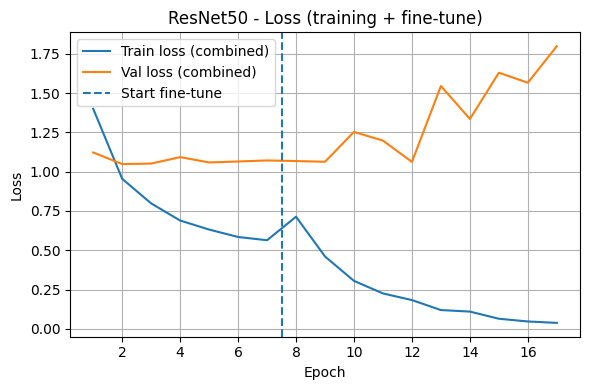

In [64]:
import matplotlib.pyplot as plt

def plot_training_and_finetune(
    base_history,
    ft_history,
    title_prefix="ResNet50"
):

    base_acc= base_history.history.get("accuracy", [])
    base_val_acc = base_history.history.get("val_accuracy", [])
    base_loss = base_history.history.get("loss", [])
    base_val_loss = base_history.history.get("val_loss", [])

    # finetune
    ft_acc = ft_history.history.get("accuracy", [])
    ft_val_acc = ft_history.history.get("val_accuracy", [])
    ft_loss = ft_history.history.get("loss", [])
    ft_val_loss = ft_history.history.get("val_loss", [])

    # Epoch ranges
    base_epochs = range(1, len(base_acc) + 1)
    ft_epochs = range(1, len(ft_acc) + 1)

    # Combined metrics
    comb_acc= base_acc + ft_acc
    comb_val_acc = base_val_acc + ft_val_acc
    comb_loss = base_loss + ft_loss
    comb_val_loss = base_val_loss + ft_val_loss
    comb_epochs= range(1, len(comb_acc) + 1)
    ft_start_epoch = len(base_acc) + 1  # where fine-tune begins in combined plots


    plt.figure(figsize=(6, 4))
    plt.plot(base_epochs, base_acc, label="Train acc")
    plt.plot(base_epochs, base_val_acc, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Training phase accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(base_epochs, base_loss, label="Train loss")
    plt.plot(base_epochs, base_val_loss, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Training phase loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(ft_epochs, ft_acc, label="Train acc (fine-tune)")
    plt.plot(ft_epochs, ft_val_acc, label="Val acc (fine-tune)")
    plt.xlabel("Fine-tune epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Fine-tuning phase accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(ft_epochs, ft_loss, label="Train loss (fine-tune)")
    plt.plot(ft_epochs, ft_val_loss, label="Val loss (fine-tune)")
    plt.xlabel("Fine-tune epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Fine-tuning phase loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comb_epochs, comb_acc, label="Train acc (combined)")
    plt.plot(comb_epochs, comb_val_acc, label="Val acc (combined)")

    plt.axvline(x=ft_start_epoch - 0.5, linestyle="--", label="Start fine-tune")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy (training + fine-tune)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comb_epochs, comb_loss, label="Train loss (combined)")
    plt.plot(comb_epochs, comb_val_loss, label="Val loss (combined)")

    # Mark where fine-tuning starts
    plt.axvline(x=ft_start_epoch - 0.5, linestyle="--", label="Start fine-tune")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss (training + fine-tune)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example call (use your actual variable names):
plot_training_and_finetune(history_resnet, history_resnet_finetune, title_prefix="ResNet50")


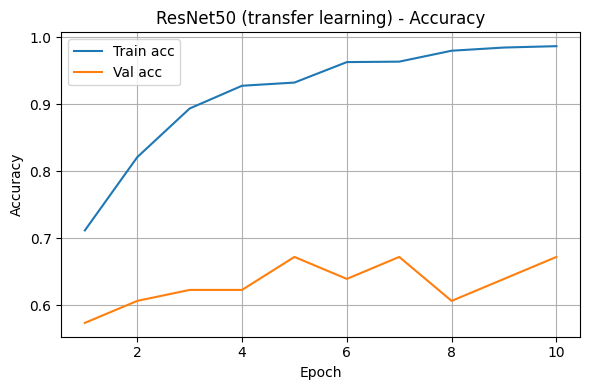

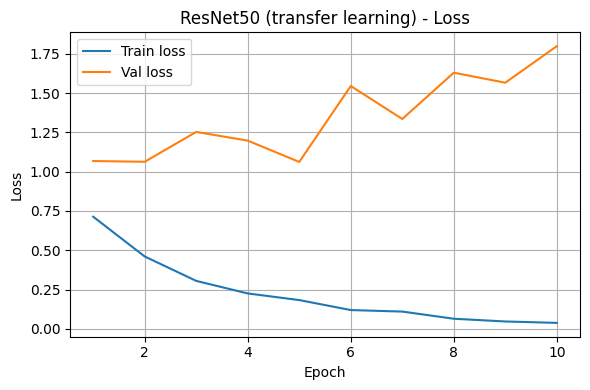

In [65]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="ResNet50"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, label='Train acc')
    plt.plot(epochs, val_acc, label='Val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix} - Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, label='Train loss')
    plt.plot(epochs, val_loss, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix} - Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call this with your history object:
plot_history(history_resnet_finetune, "ResNet50 (transfer learning)")

In [66]:
from sklearn.metrics import classification_report

test_generator.reset()
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
y_prob = resnet_model.predict(test_generator)       # shape: (N, num_classes)
y_pred = np.argmax(y_prob, axis=1)


report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    output_dict=True
)
test_accuracy      = report["accuracy"]            # overall accuracy
macro_precision    = report["macro avg"]["precision"]
macro_recall       = report["macro avg"]["recall"]
macro_f1           = report["macro avg"]["f1-score"]

print("=== ResNet50 summary metrics (use these in the table) ===")
print(f"Test Accuracy:      {test_accuracy * 100:.2f}%")
print(f"Average Precision:  {macro_precision * 100:.2f}%")
print(f"Average Recall:     {macro_recall * 100:.2f}%")
print(f"Average F1-score:   {macro_f1 * 100:.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
=== ResNet50 summary metrics (use these in the table) ===
Test Accuracy:      74.63%
Average Precision:  73.54%
Average Recall:     73.32%
Average F1-score:   72.80%


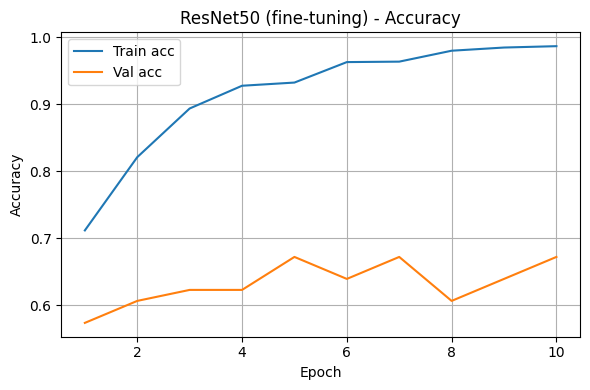

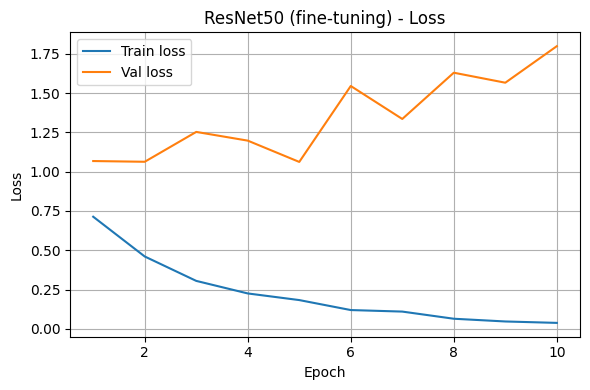

In [67]:
plot_history(history_resnet_finetune, "ResNet50 (fine-tuning)")

# EfficientNetV2B0

In [68]:
effnet_base = EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# freeze
effnet_base.trainable = False

x = effnet_base.output
x = GlobalAveragePooling2D()(x)        # pool spatial features
x = Dense(256, activation='relu')(x)   # small dense layer
x = Dropout(0.5)(x)                    #dropout for regularization
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

effnet_model = Model(inputs=effnet_base.input, outputs=outputs)

effnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          0 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,248,276 (23.84 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [69]:
effnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [70]:
train_generator, val_generator, test_generator = get_generator("EfficientNetV2B0")

Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.


In [71]:
print("AFTER get_generator:")
print("Train:", train_generator.samples, train_generator.class_indices)
print("Val:  ", val_generator.samples,   val_generator.class_indices)
print("Test: ", test_generator.samples,  test_generator.class_indices)

x_tr, _ = next(train_generator)
x_val, _ = next(val_generator)
x_te, _  = next(test_generator)

print("Ranges:")
print("Train:", x_tr.min(), x_tr.max())
print("Val:  ", x_val.min(), x_val.max())
print("Test: ", x_te.min(), x_te.max())

AFTER get_generator:
Train: 1474 {'pothos_healthy': 0, 'pothos_leaf_spot': 1, 'pothos_pests': 2, 'pothos_root_rot': 3}
Val:   61 {'pothos_healthy': 0, 'pothos_leaf_spot': 1, 'pothos_pests': 2, 'pothos_root_rot': 3}
Test:  67 {'pothos_healthy': 0, 'pothos_leaf_spot': 1, 'pothos_pests': 2, 'pothos_root_rot': 3}
Ranges:
Train: 0.0 255.0
Val:   0.0 255.0
Test:  0.0 255.0


In [72]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
classes = np.unique(labels)

weights = compute_class_weight( #pest and root condition classes smaller, weight all classes to help training
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weight = {i: w for i, w in enumerate(weights)} #assign weights
print("class_weight:", class_weight)

early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # stop if it doesn't improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,           # after 2 epochs with no improvement
    min_lr=1e-7
)

history_effnet = effnet_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

class_weight: {0: np.float64(0.7924731182795699), 1: np.float64(0.9448717948717948), 2: np.float64(1.28397212543554), 3: np.float64(1.1099397590361446)}
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4430 - loss: 1.2767 - val_accuracy: 0.5082 - val_loss: 1.1120 - learning_rate: 1.0000e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 469ms/step - accuracy: 0.6085 - loss: 1.0170 - val_accuracy: 0.5082 - val_loss: 1.0299 - learning_rate: 1.0000e-04
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 488ms/step - accuracy: 0.6703 - loss: 0.8965 - val_accuracy: 0.5246 - val_loss: 0.9940 - learning_rate: 1.0000e-04
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 489ms/step - accuracy: 0.6913 - loss: 0.8116 - val_accuracy: 0.5574 - val_loss: 1.0024 - learning_rate: 1.0000e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.7259 - loss: 0.7493 - val_accuracy: 0.5246 - val_loss: 0.9776 - learning_rate: 1.0000e-04
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 489ms/step - accuracy: 

In [73]:
test_loss, test_acc = effnet_model.evaluate(test_generator)
print(f"EffNetv2B0 test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.6716 - loss: 0.8100
EffNetv2B0 test accuracy: 0.6716, test loss: 0.8100


In [74]:
effnet_base.trainable = True

fine_tune_from = len(effnet_base.layers) - 60

for i, layer in enumerate(effnet_base.layers):
    if i < fine_tune_from:# Freeze all layers before fine_tune_from
        layer.trainable = False
    else:
        # In the fine-tuning region: keep BatchNorm frozen (more stable) train everything else.
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

trainable_layers = sum(l.trainable for l in effnet_base.layers)
frozen_layers    = sum(not l.trainable for l in effnet_base.layers)
print("Trainable layers in effnet_base :", trainable_layers)
print("Frozen layers in effnet_base    :", frozen_layers)

effnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10

history_effnet_finetune = effnet_model.fit(
    train_generator,
    epochs=fine_tune_epochs,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

Trainable layers in effnet_base : 48
Frozen layers in effnet_base    : 222
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8358 - loss: 0.4848 - val_accuracy: 0.5738 - val_loss: 0.9498 - learning_rate: 1.0000e-05
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 466ms/step - accuracy: 0.8609 - loss: 0.4445 - val_accuracy: 0.5738 - val_loss: 0.9594 - learning_rate: 1.0000e-05
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 497ms/step - accuracy: 0.8521 - loss: 0.4508 - val_accuracy: 0.5738 - val_loss: 0.9663 - learning_rate: 5.0000e-06
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.8514 - loss: 0.4340 - val_accuracy: 0.5738 - val_loss: 0.9639 - learning_rate: 5.0000e-06
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 475ms/step - accuracy: 0.8474 - loss: 0.4292 - val_accuracy: 0.5738 - val_loss: 0.9624 - learning_rate: 2.5000e-06


In [75]:
test_loss, test_acc = effnet_model.evaluate(test_generator)
print(f"EffNetv2B0 fine tune test accuracy: {test_acc:.4f}, test fine tune loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7015 - loss: 0.8296
EffNetv2B0 fine tune test accuracy: 0.7015, test fine tune loss: 0.8296


3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
Confusion matrix (raw counts):
[[19  1  0  1]
 [ 3  8  5  2]
 [ 0  2 10  1]
 [ 2  0  3 10]]


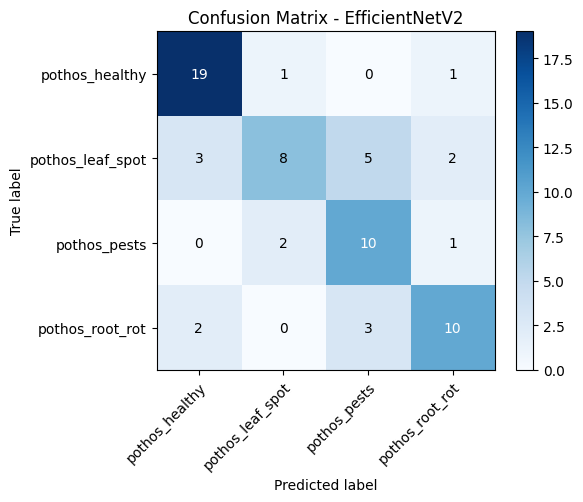


Classification report:
                  precision    recall  f1-score   support

  pothos_healthy       0.79      0.90      0.84        21
pothos_leaf_spot       0.73      0.44      0.55        18
    pothos_pests       0.56      0.77      0.65        13
 pothos_root_rot       0.71      0.67      0.69        15

        accuracy                           0.70        67
       macro avg       0.70      0.70      0.68        67
    weighted avg       0.71      0.70      0.69        67



In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()  # just in case
y_true = test_generator.classes                     # integer labels
class_labels = list(test_generator.class_indices.keys())

y_prob = effnet_model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (raw counts):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(class_labels)),
    yticks=np.arange(len(class_labels)),
    xticklabels=class_labels,
    yticklabels=class_labels,
    ylabel='True label',
    xlabel='Predicted label',
    title='Confusion Matrix - EfficientNetV2'
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


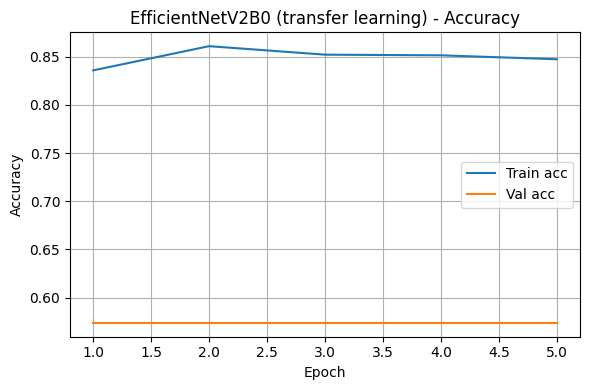

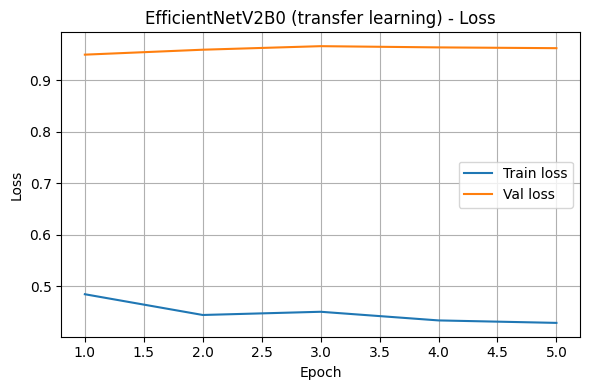

In [77]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="EfficientNetV2B0"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, label='Train acc')
    plt.plot(epochs, val_acc, label='Val acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix} - Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, label='Train loss')
    plt.plot(epochs, val_loss, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix} - Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call this with your history object:
plot_history(history_effnet_finetune, "EfficientNetV2B0 (transfer learning)")

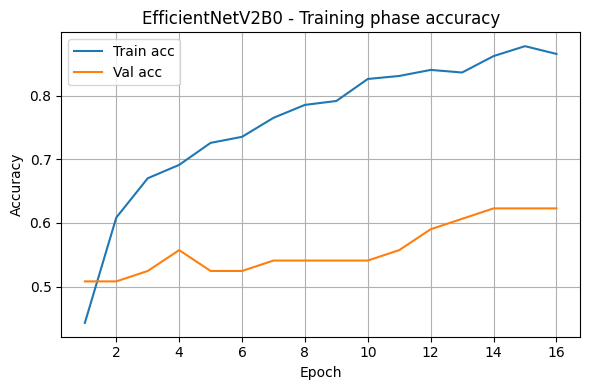

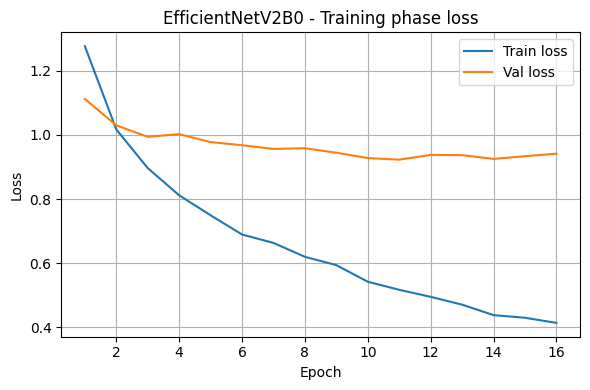

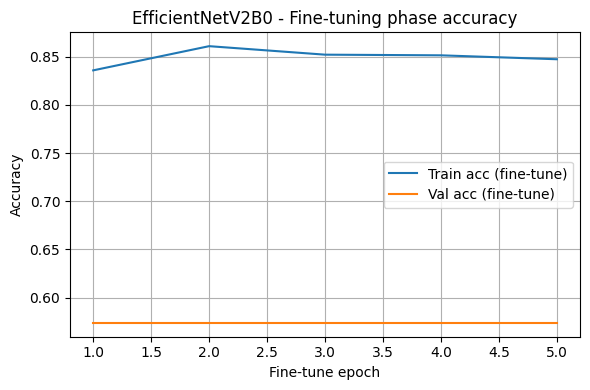

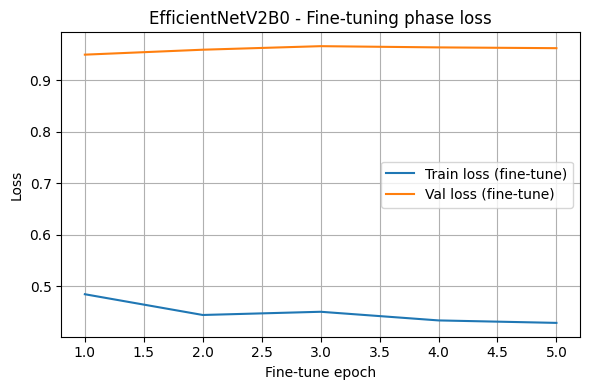

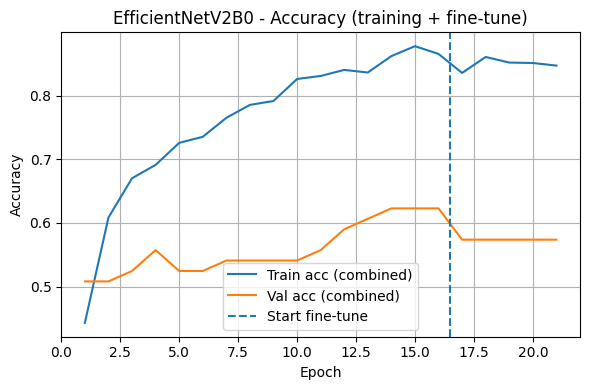

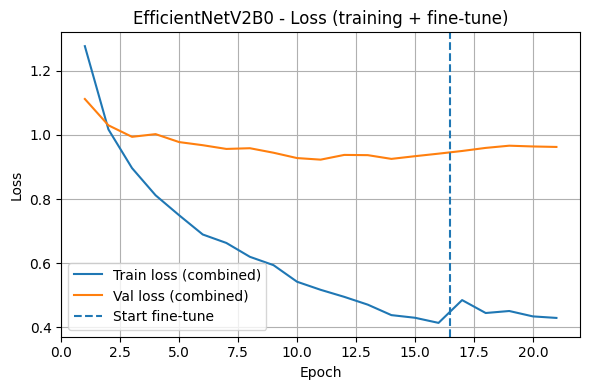

In [78]:
import matplotlib.pyplot as plt

def plot_training_and_finetune(
    base_history,
    ft_history,
    title_prefix="EfficientNetV2B0"
):

    # Base phase
    base_acc= base_history.history.get("accuracy", [])
    base_val_acc = base_history.history.get("val_accuracy", [])
    base_loss = base_history.history.get("loss", [])
    base_val_loss = base_history.history.get("val_loss", [])

    # finetune
    ft_acc = ft_history.history.get("accuracy", [])
    ft_val_acc = ft_history.history.get("val_accuracy", [])
    ft_loss = ft_history.history.get("loss", [])
    ft_val_loss = ft_history.history.get("val_loss", [])

    # Epoch ranges
    base_epochs = range(1, len(base_acc) + 1)
    ft_epochs = range(1, len(ft_acc) + 1)

    # Combined metrics
    comb_acc= base_acc + ft_acc
    comb_val_acc = base_val_acc + ft_val_acc
    comb_loss = base_loss + ft_loss
    comb_val_loss = base_val_loss + ft_val_loss
    comb_epochs= range(1, len(comb_acc) + 1)
    ft_start_epoch = len(base_acc) + 1  # where fine-tune begins in combined plots

    plt.figure(figsize=(6, 4))
    plt.plot(base_epochs, base_acc, label="Train acc")
    plt.plot(base_epochs, base_val_acc, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Training phase accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(base_epochs, base_loss, label="Train loss")
    plt.plot(base_epochs, base_val_loss, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Training phase loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(ft_epochs, ft_acc, label="Train acc (fine-tune)")
    plt.plot(ft_epochs, ft_val_acc, label="Val acc (fine-tune)")
    plt.xlabel("Fine-tune epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Fine-tuning phase accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(ft_epochs, ft_loss, label="Train loss (fine-tune)")
    plt.plot(ft_epochs, ft_val_loss, label="Val loss (fine-tune)")
    plt.xlabel("Fine-tune epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Fine-tuning phase loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comb_epochs, comb_acc, label="Train acc (combined)")
    plt.plot(comb_epochs, comb_val_acc, label="Val acc (combined)")

    # mark where fine-tuning starts
    plt.axvline(x=ft_start_epoch - 0.5, linestyle="--", label="Start fine-tune")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy (training + fine-tune)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comb_epochs, comb_loss, label="Train loss (combined)")
    plt.plot(comb_epochs, comb_val_loss, label="Val loss (combined)")

    # Mark wheere fine-tuning starts
    plt.axvline(x=ft_start_epoch - 0.5, linestyle="--", label="Start fine-tune")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss (training + fine-tune)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_training_and_finetune(history_effnet, history_effnet_finetune, title_prefix="EfficientNetV2B0")


MobilenetV2

In [79]:
mobnet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# freeze
mobnet_base.trainable = False

x = mobnet_base.output
x = GlobalAveragePooling2D()(x)        # pool spatial features
x = Dense(256, activation='relu')(x)   # small dense layer
x = Dropout(0.5)(x)                    #dropout for regularization
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

mobnet_model = Model(inputs=mobnet_base.input, outputs=outputs)

mobnet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [80]:
mobnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
train_generator, val_generator, test_generator = get_generator("MobileNetV2")

Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.


In [82]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
classes = np.unique(labels)

weights = compute_class_weight( #pest and root condition classes smaller, weight all classes to help training
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weight = {i: w for i, w in enumerate(weights)} #assign weights
print("class_weight:", class_weight)

early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # stop if it doesn't improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,           # after 2 epochs with no improvement
    min_lr=1e-7
)

history_mobnet = mobnet_model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

class_weight: {0: np.float64(0.7924731182795699), 1: np.float64(0.9448717948717948), 2: np.float64(1.28397212543554), 3: np.float64(1.1099397590361446)}
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 56s 985ms/step - accuracy: 0.3833 - loss: 1.4574 - val_accuracy: 0.4426 - val_loss: 1.2238 - learning_rate: 1.0000e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 494ms/step - accuracy: 0.5977 - loss: 1.0149 - val_accuracy: 0.4754 - val_loss: 1.1744 - learning_rate: 1.0000e-04
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 471ms/step - accuracy: 0.6588 - loss: 0.8872 - val_accuracy: 0.4754 - val_loss: 1.1900 - learning_rate: 1.0000e-04
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 477ms/step - accuracy: 0.6981 - loss: 0.7978 - val_accuracy: 0.5574 - val_loss: 1.1553 - learning_rate: 1.0000e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 496ms/step - accuracy: 0.7307 - loss: 0.7395 - val_accuracy: 0.5410 - val_loss: 1.1462 - learning_rate: 1.0000e-04
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accurac

In [83]:
test_loss, test_acc = mobnet_model.evaluate(test_generator)
print(f"MobileNetV2 test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.7015 - loss: 0.8795
MobileNetV2 test accuracy: 0.7015, test loss: 0.8795


In [84]:
mobnet_base.trainable = True

fine_tune_from = len(mobnet_base.layers) - 40

for i, layer in enumerate(mobnet_base.layers):
    if i < fine_tune_from: # earlier layers stay frozen
        layer.trainable = False
    else:
        # keep BatchNorm frozen train everything else.
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

trainable_layers = sum(l.trainable for l in mobnet_base.layers)
frozen_layers    = sum(not l.trainable for l in mobnet_base.layers)
print("Trainable layers in mobilenet_base :", trainable_layers)
print("Frozen layers in mobilenet_base    :", frozen_layers)

mobnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10

history_mobnet_finetune = mobnet_model.fit(
    train_generator,
    epochs=fine_tune_epochs,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)


Trainable layers in mobilenet_base : 26
Frozen layers in mobilenet_base    : 128
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 781ms/step - accuracy: 0.7653 - loss: 0.6261 - val_accuracy: 0.5574 - val_loss: 1.1604 - learning_rate: 1.0000e-05
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 479ms/step - accuracy: 0.7951 - loss: 0.5366 - val_accuracy: 0.5082 - val_loss: 1.2241 - learning_rate: 1.0000e-05
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 491ms/step - accuracy: 0.8345 - loss: 0.4738 - val_accuracy: 0.5574 - val_loss: 1.2199 - learning_rate: 5.0000e-06
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 456ms/step - accuracy: 0.8507 - loss: 0.4349 - val_accuracy: 0.5574 - val_loss: 1.2185 - learning_rate: 5.0000e-06
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 482ms/step - accuracy: 0.8494 - loss: 0.4285 - val_accuracy: 0.5574 - val_loss: 1.2342 - learning_rate: 2.5000e-06


In [85]:
test_loss, test_acc = mobnet_model.evaluate(test_generator)
print(f"mobNet fine tune test accuracy: {test_acc:.4f}, test fine tune loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6418 - loss: 0.8875
mobNet fine tune test accuracy: 0.6418, test fine tune loss: 0.8875


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
Confusion matrix (raw counts):
[[15  3  1  2]
 [ 0 10  7  1]
 [ 0  2 11  0]
 [ 1  3  4  7]]


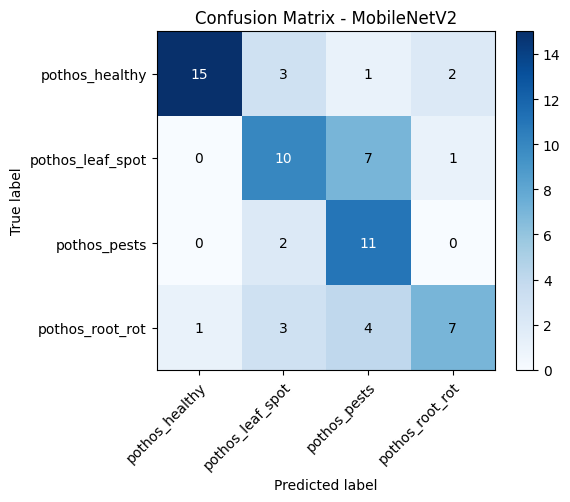


Classification report:
                  precision    recall  f1-score   support

  pothos_healthy       0.94      0.71      0.81        21
pothos_leaf_spot       0.56      0.56      0.56        18
    pothos_pests       0.48      0.85      0.61        13
 pothos_root_rot       0.70      0.47      0.56        15

        accuracy                           0.64        67
       macro avg       0.67      0.65      0.63        67
    weighted avg       0.69      0.64      0.65        67



In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()  # just in case
y_true = test_generator.classes                     # integer labels
class_labels = list(test_generator.class_indices.keys())

y_prob = mobnet_model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (raw counts):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(class_labels)),
    yticks=np.arange(len(class_labels)),
    xticklabels=class_labels,
    yticklabels=class_labels,
    ylabel='True label',
    xlabel='Predicted label',
    title='Confusion Matrix - MobileNetV2'
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


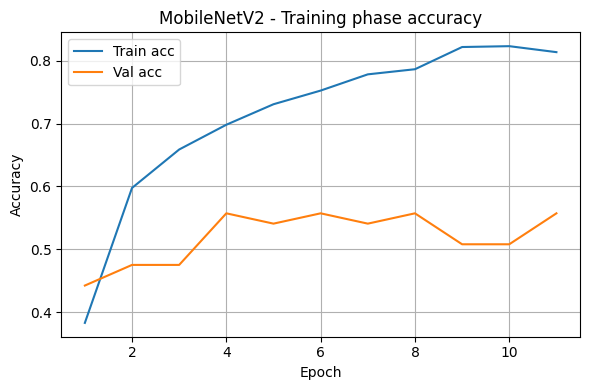

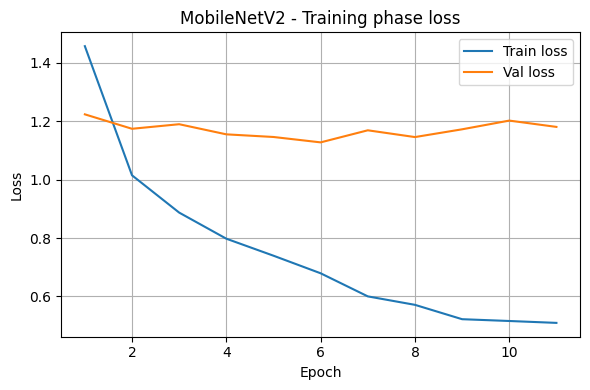

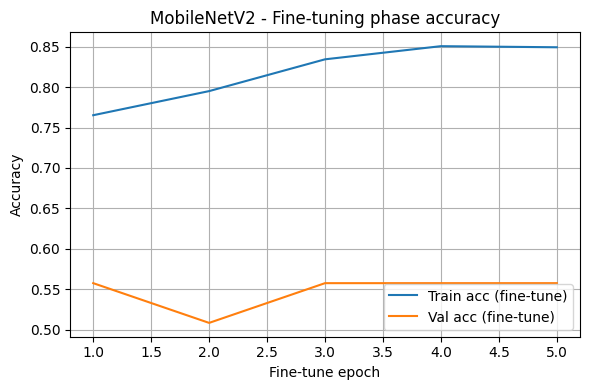

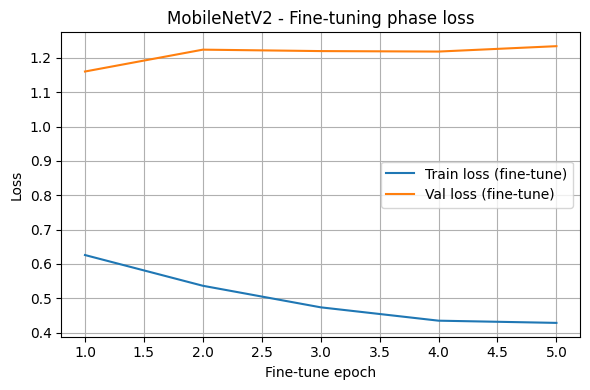

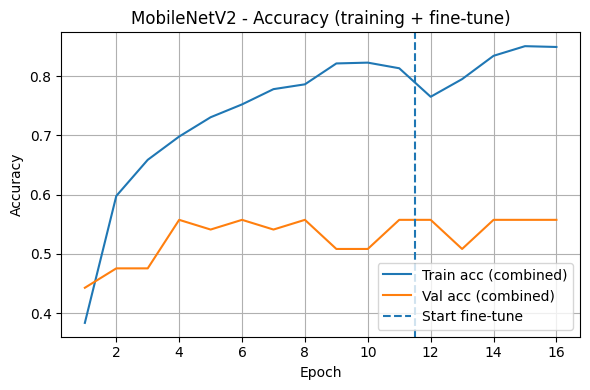

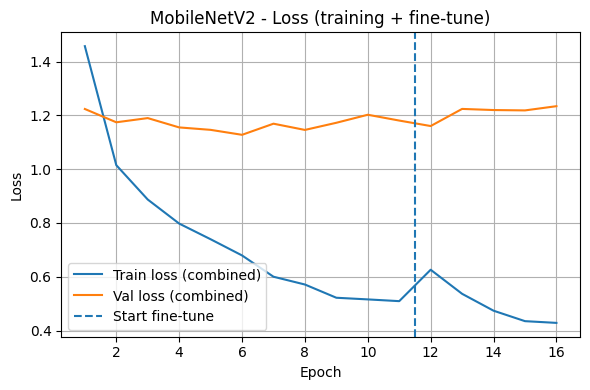

In [87]:
import matplotlib.pyplot as plt

def plot_training_and_finetune(
    base_history,
    ft_history,
    title_prefix="MobileNetV2"
):
    """
    base_history: History from initial training (frozen base)
    ft_history:   History from fine-tuning run (partially unfrozen base)
    """

    base_acc= base_history.history.get("accuracy", [])
    base_val_acc = base_history.history.get("val_accuracy", [])
    base_loss = base_history.history.get("loss", [])
    base_val_loss = base_history.history.get("val_loss", [])

    # finetune phase
    ft_acc = ft_history.history.get("accuracy", [])
    ft_val_acc = ft_history.history.get("val_accuracy", [])
    ft_loss = ft_history.history.get("loss", [])
    ft_val_loss = ft_history.history.get("val_loss", [])

    # Epoch ranges
    base_epochs = range(1, len(base_acc) + 1)
    ft_epochs = range(1, len(ft_acc) + 1)

    comb_acc= base_acc + ft_acc
    comb_val_acc = base_val_acc + ft_val_acc
    comb_loss = base_loss + ft_loss
    comb_val_loss = base_val_loss + ft_val_loss
    comb_epochs= range(1, len(comb_acc) + 1)
    ft_start_epoch = len(base_acc) + 1  # where fine-tune begins in combined plots

    plt.figure(figsize=(6, 4))
    plt.plot(base_epochs, base_acc, label="Train acc")
    plt.plot(base_epochs, base_val_acc, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Training phase accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(base_epochs, base_loss, label="Train loss")
    plt.plot(base_epochs, base_val_loss, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Training phase loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(ft_epochs, ft_acc, label="Train acc (fine-tune)")
    plt.plot(ft_epochs, ft_val_acc, label="Val acc (fine-tune)")
    plt.xlabel("Fine-tune epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Fine-tuning phase accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(ft_epochs, ft_loss, label="Train loss (fine-tune)")
    plt.plot(ft_epochs, ft_val_loss, label="Val loss (fine-tune)")
    plt.xlabel("Fine-tune epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Fine-tuning phase loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comb_epochs, comb_acc, label="Train acc (combined)")
    plt.plot(comb_epochs, comb_val_acc, label="Val acc (combined)")

    # mark where finetuning starts
    plt.axvline(x=ft_start_epoch - 0.5, linestyle="--", label="Start fine-tune")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy (training + fine-tune)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(comb_epochs, comb_loss, label="Train loss (combined)")
    plt.plot(comb_epochs, comb_val_loss, label="Val loss (combined)")

    plt.axvline(x=ft_start_epoch - 0.5, linestyle="--", label="Start fine-tune")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss (training + fine-tune)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_training_and_finetune(history_mobnet, history_mobnet_finetune, title_prefix="MobileNetV2")


In [88]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

models = [
    ("ResNet50",        resnet_model),
    ("EfficientNetV2B0", effnet_model),
    ("MobileNetV2",     mobnet_model),
]

results = []

for backbone_name, model in models:
    print(f"Evaluating {backbone_name} on test set...")
    _, _, test_generator = get_generator(backbone_name)

    # True labels from generator
    y_true = test_generator.classes
    class_labels = sorted(np.unique(y_true))

    # Evaluate loss adn accuracy
    test_generator.reset()
    test_loss, test_acc = model.evaluate(test_generator, verbose=0)

    # predict probabilities and class labels
    test_generator.reset()
    y_proba = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    #metrics
    macro_precision = precision_score(
        y_true, y_pred, labels=class_labels,
        average="macro", zero_division=0
    )
    macro_recall = recall_score(
        y_true, y_pred, labels=class_labels,
        average="macro", zero_division=0
    )
    macro_f1 = f1_score(
        y_true, y_pred, labels=class_labels,
        average="macro", zero_division=0
    )
    weighted_f1 = f1_score(
        y_true, y_pred, labels=class_labels,
        average="weighted", zero_division=0
    )
    params_millions = model.count_params() / 1e6
    results.append({
        "Model": backbone_name,
        "Test Accuracy": round(test_acc, 4),
        "Test Loss": round(test_loss, 4),
        "Macro Precision": round(macro_precision, 4),
        "Macro Recall": round(macro_recall, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Params (Millions)": round(params_millions, 2),
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
display(results_df)


Evaluating ResNet50 on test set...
Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.
Evaluating EfficientNetV2B0 on test set...
Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.
Evaluating MobileNetV2 on test set...
Found 1474 images belonging to 4 classes.
Found 61 images belonging to 4 classes.
Found 67 images belonging to 4 classes.


,Model,Test Accuracy,Test Loss,Macro Precision,Macro Recall,Macro F1,Weighted F1,Params (Millions)
0,ResNet50,0.7463,1.1437,0.7354,0.7332,0.7280,0.7408,24.11
1,EfficientNetV2B0,0.7015,0.8296,0.6972,0.6963,0.6827,0.6925,6.25
2,MobileNetV2,0.6418,0.8875,0.6678,0.6457,0.6344,0.6473,2.59
